In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
df = pd.read_csv( 'cancer_classification.csv')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [49]:
df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [50]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


<AxesSubplot: xlabel='benign_0__mal_1', ylabel='count'>

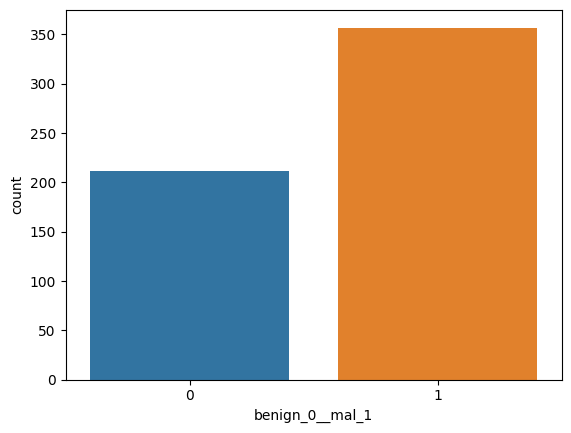

In [51]:
sns.countplot(x='benign_0__mal_1', data=df)

<AxesSubplot: >

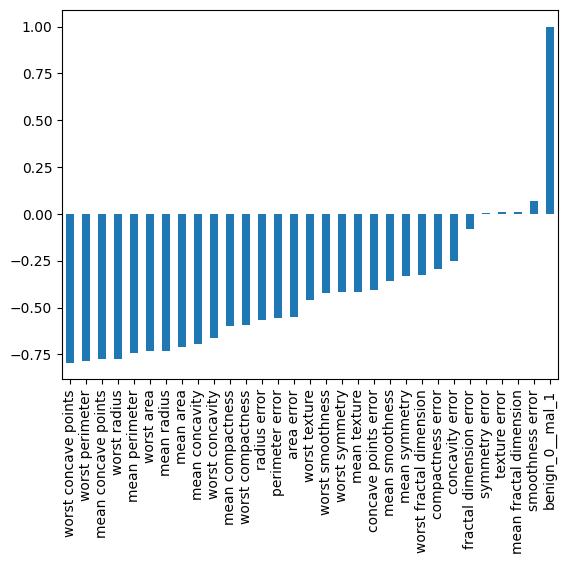

In [52]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

In [53]:
X= df.drop('benign_0__mal_1', axis=1).values
y= df['benign_0__mal_1'].values

In [54]:
X.shape

(569, 30)

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
y.shape

(569,)

In [57]:
X_train,X_test, y_train,y_test= train_test_split(X, y, test_size=0.25, random_state=101)

In [58]:
from sklearn.preprocessing import MinMaxScaler

In [59]:
scaler = MinMaxScaler()

In [60]:
X_train = scaler.fit_transform(X_train)

In [61]:
X_test = scaler.transform(X_test)

In [16]:
y_test.shape

(143,)

In [17]:
X_test.shape

(143, 30)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [19]:
X_train.shape

(426, 30)

In [20]:
y_train.shape

(426,)

In [21]:
model = Sequential()

model.add(Dense(units=30,activation='relu'),)
model.add(Dense(units=15,activation='relu'),)

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [ ]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test))

In [23]:
loss = pd.DataFrame(model.history.history)

<AxesSubplot: >

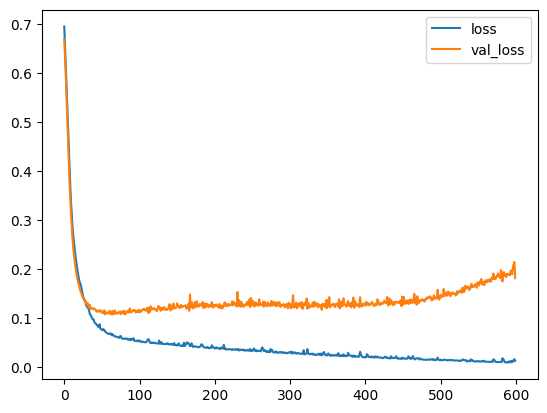

In [25]:
loss.plot()

In [64]:
model = Sequential()

model.add(Dense(units=30,activation='relu'),)
model.add(Dense(units=15,activation='relu'),)

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [65]:
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
help(EarlyStopping)

Help on class EarlyStopping in module keras.callbacks:

class EarlyStopping(Callback)
 |  EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False, start_from_epoch=0)
 |  
 |  Stop training when a monitored metric has stopped improving.
 |  
 |  Assuming the goal of a training is to minimize the loss. With this, the
 |  metric to be monitored would be `'loss'`, and mode would be `'min'`. A
 |  `model.fit()` training loop will check at end of every epoch whether
 |  the loss is no longer decreasing, considering the `min_delta` and
 |  `patience` if applicable. Once it's found no longer decreasing,
 |  `model.stop_training` is marked True and the training terminates.
 |  
 |  The quantity to be monitored needs to be available in `logs` dict.
 |  To make it so, pass the loss or metrics at `model.compile()`.
 |  
 |  Args:
 |    monitor: Quantity to be monitored.
 |    min_delta: Minimum change in the monitored quantity
 

In [66]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [67]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test), callbacks=[early_stop])

Epoch 1/600
14/14 [==============================] - 1s 10ms/step - loss: 0.6686 - val_loss: 0.6483
Epoch 2/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6280 - val_loss: 0.6040
Epoch 3/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5834 - val_loss: 0.5582
Epoch 4/600
14/14 [==============================] - 0s 4ms/step - loss: 0.5408 - val_loss: 0.5145
Epoch 5/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4991 - val_loss: 0.4752
Epoch 6/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4609 - val_loss: 0.4342
Epoch 7/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4229 - val_loss: 0.3943
Epoch 8/600
14/14 [==============================] - 0s 3ms/step - loss: 0.3860 - val_loss: 0.3580
Epoch 9/600
14/14 [==============================] - 0s 4ms/step - loss: 0.3506 - val_loss: 0.3209
Epoch 10/600
14/14 [==============================] - 0s 4ms/step - loss: 0.3195 - val_loss: 0.2925
Epoch 11

<AxesSubplot: >

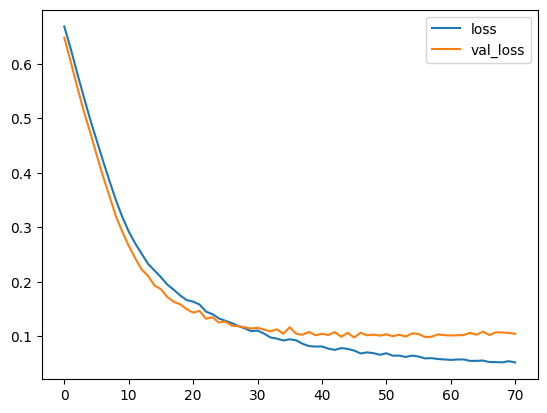

In [68]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [70]:
from tensorflow.keras.layers import Dropout

In [72]:
model = Sequential()

model.add(Dense(units=30,activation='relu'))
model.add(Dropout(rate=0.5))

model.add(Dense(units=15,activation='relu'))
model.add(Dropout(rate=0.5))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [73]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test), callbacks=[early_stop])

Epoch 1/600
14/14 [==============================] - 0s 7ms/step - loss: 0.7354 - val_loss: 0.7045
Epoch 2/600
14/14 [==============================] - 0s 2ms/step - loss: 0.7044 - val_loss: 0.6901
Epoch 3/600
14/14 [==============================] - 0s 2ms/step - loss: 0.7054 - val_loss: 0.6752
Epoch 4/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6846 - val_loss: 0.6627
Epoch 5/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6811 - val_loss: 0.6529
Epoch 6/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6488 - val_loss: 0.6415
Epoch 7/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6514 - val_loss: 0.6282
Epoch 8/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6336 - val_loss: 0.6109
Epoch 9/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6213 - val_loss: 0.5920
Epoch 10/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5946 - val_loss: 0.5650
Epoch 11/

In [74]:
model_loss = pd.DataFrame(model.history.history)

<AxesSubplot: >

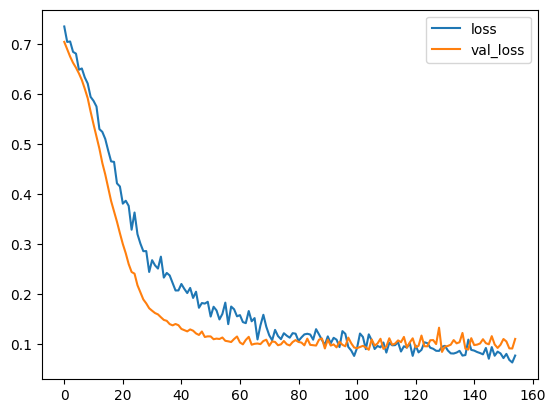

In [75]:
model_loss.plot()

In [78]:
prediction = (model.predict(X_test)>0.5).astype("int32")

5/5 [==============================] - 0s 789us/step


In [79]:
from sklearn.metrics import classification_report,confusion_matrix

In [80]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96        55
           1       0.99      0.95      0.97        88

    accuracy                           0.97       143
   macro avg       0.96      0.97      0.96       143
weighted avg       0.97      0.97      0.97       143



In [81]:
print(confusion_matrix(y_test,prediction))

[[54  1]
 [ 4 84]]
